In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
df = pd.read_csv ("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [41]:
df.shape

(8807, 12)

In [42]:
df ['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

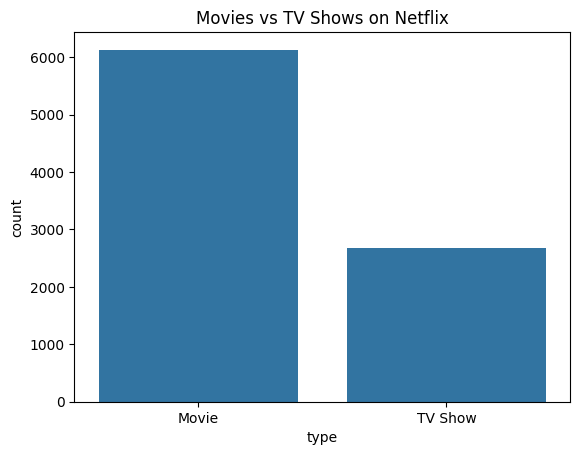

In [43]:
sns.countplot(data=df, x="type")
plt.title ("Movies vs TV Shows on Netflix")
plt.savefig("../visuals/movies_vs_tv.png", bbox_inches="tight")
plt.show()

In [44]:
### Movies vs TV shows on Netflix 
### The data set shows that movies dominate Netflix's Catalog, while TV shows make up a smaller but still significant portion of the platforms's content.

In [45]:
df[ 'release_year'].value_counts().head()
#this shows which year have the most Netflix titles.

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

In [46]:
year_counts = df['release_year'].value_counts().sort_index()
#counts how many titles were released each year and sorts the results by year.

<function matplotlib.pyplot.show(close=None, block=None)>

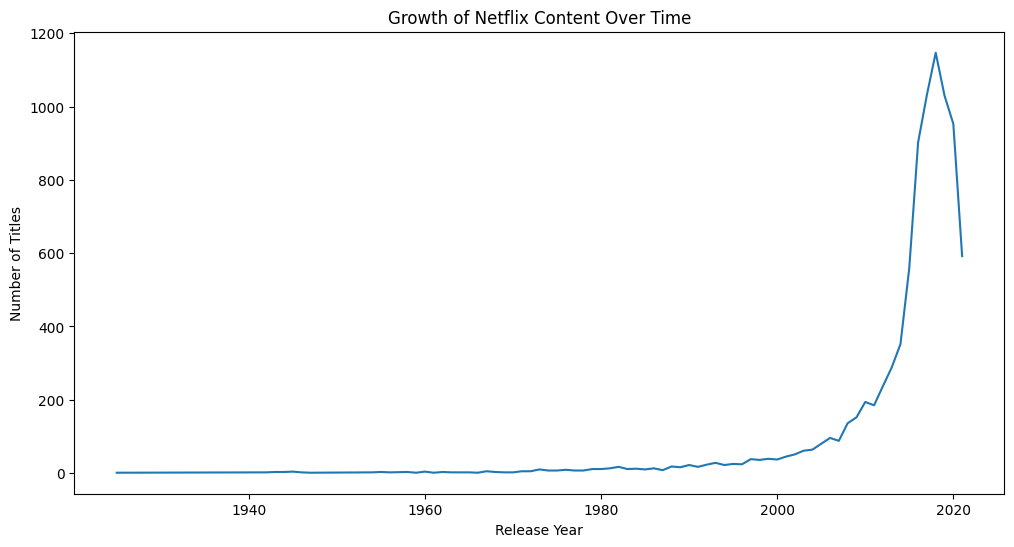

In [47]:
plt.figure(figsize=(12, 6))

plt.plot(year_counts)

plt.title('Growth of Netflix Content Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.savefig("../visuals/netflix_growth_over_time.png")

plt.show


In [48]:
#Growth of Netflix Content Over Time
#The line graph illustrates the growth of Netflix's content library over time, showing a significant increase in the number of titles released each year, particularly in recent years. 
#As the size of the catalog increases, users are presented with a wider variety of content to choose from, which may contribute to the sense of choice fatigue reported during the user interviews.

In [49]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str

In [50]:
genres = df['listed_in'].str.split(',' ,expand=True).stack()

In [51]:
genres_counts = genres.value_counts()
genres_counts.head(10)
#To find rhe most common genre 

 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64

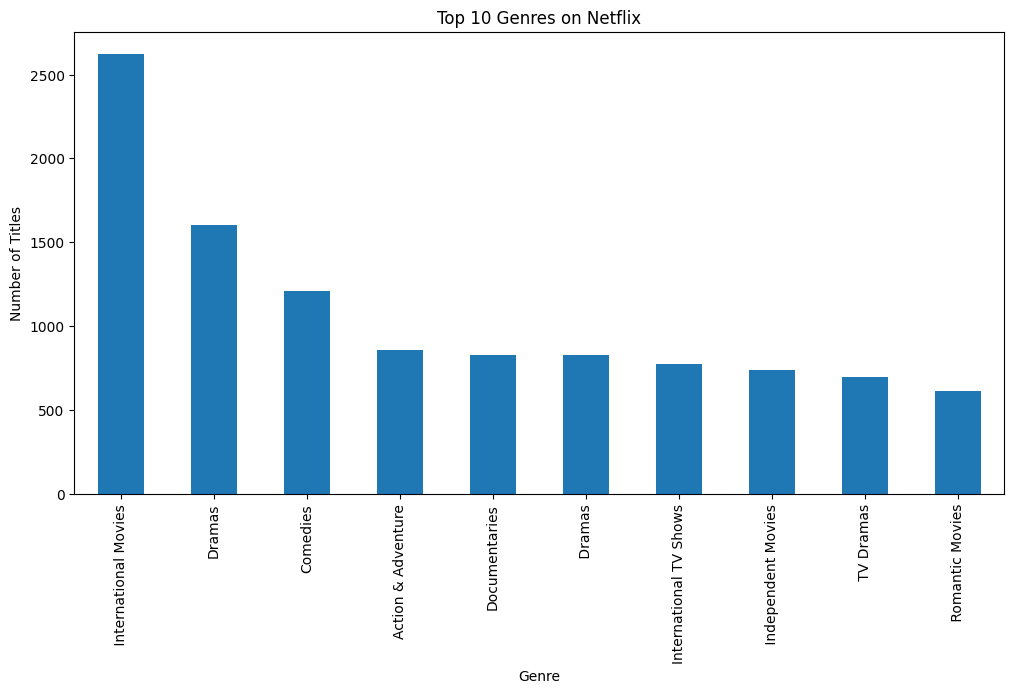

In [52]:
plt.figure(figsize=(12, 6))
genres_counts.head(10).plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.savefig("../visuals/genre_distribution.png")

plt.show()

In [53]:
#The analysis shows that a small number of genres dominate Netflix's content library, with "Dramas" being the most prevalent genre, followed by "Comedies" and "Documentaries".
#This concentration of similar genres may contribute to the sense of choice fatigue, as users may feel overwhelmed by the abundance of content within a few popular categories, making it difficult to find something new or different to watch.
# This analysis also highlights  that International movies is the most common genre this suggests that Netflix has significantly expanded its global content library in recent years. Along with genres such as Drama and Comedy, a large number of titles fall within dominant categories. 

In [54]:
countries = df['country'].dropna().str.split(',' ,expand=True).stack()

In [55]:
country_counts = countries.value_counts()
country_counts.head(10)

United States     3211
India             1008
United Kingdom     628
 United States     479
Canada             271
Japan              259
France             212
South Korea        211
 France            181
Spain              181
Name: count, dtype: int64

In [56]:
#The analysis shows that the United States produces the largest share of content followed by India.This presents Netflix's strong presence both in western and International markets. India's position as the second largest content producer reflects the platform's strategic focus on expanding its offerings in the rapidly growing Indian market, which has a large and diverse audience. The presence of other countries in the top 10 also indicates Netflix's commitment to providing a wide range of content from different regions, catering to a global audience and contributing to the sense of choice fatigue as users are presented with an overwhelming variety of options from around the world.

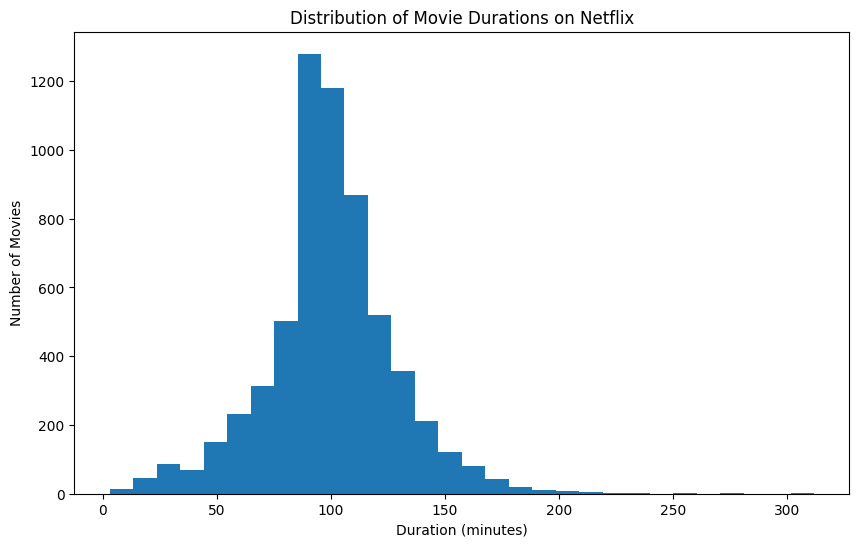

In [57]:
movies= df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10, 6))
plt.hist(movies['duration'], bins=30)
plt.title('Distribution of Movie Durations on Netflix') 
plt.xlabel('Duration (minutes)')        
plt.ylabel('Number of Movies')

plt.savefig("../visuals/movie_duration_distribution.png")

plt.show()
         
